# Random forest training for insurance claim amout
In this notebook, we use scikit-learn to train a Random Forest model that predicts the claim amount a customer is likely to request from the insurance company after an accident, based on their profile.

The model is trained directly on the raw data in csv format and not on the SQL data. 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, mean_squared_log_error

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer

In [3]:
# 1. Load dataset
data = pd.read_csv('../data/raw/historic_dataset.csv')  # Note to dev: before it was trainset.csv
data.head()

,ID,Insurance_Coverage_Days,Insured_Age,Insured_Sex,Insured_Status,Insured_NoClaimYears,Insured_CreditScore,Insured_RegionID,Insured_DriveArea,Car_Use,...,Brake_06ms2_1000km,Brake_07ms2_1000km,LeftTurn_Low_1000km,LeftTurn_Med_1000km,LeftTurn_High_1000km,RightTurn_Low_1000km,RightTurn_Med_1000km,RightTurn_High_1000km,AMT_Claim,NB_Claim
0,25859,365,48,Male,Single,32,865,89,Rural,Private,...,0,0,10,1,0,231,44,1,0.0,0
1,10785,356,51,Female,Married,35,861,38,Urban,Commute,...,0,0,896,282,22,1173,428,39,0.0,0
2,24808,365,63,Female,Married,44,856,36,Rural,Private,...,0,0,26,3,0,125,20,0,0.0,0
3,49535,366,37,Female,Single,20,686,60,Urban,Commute,...,0,0,7,0,0,4,0,0,0.0,0
4,3346,181,50,Female,Single,23,539,38,Rural,Private,...,1,1,10,2,0,12,1,0,0.0,0


In [19]:
# drop the ID
data.drop(columns="ID",inplace=True)

KeyError: "['ID'] not found in axis"

In [ ]:
X = data.drop(columns="AMT_Claim")
y = data["AMT_Claim"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=.2)

In [ ]:
X_train.shape

(20000, 45)

In [7]:
X_test.shape

(5000, 45)

## Cose che vorrei provare

1. Istogramma di ogni feature (plot mean and variance) -> if low variance drop the features... or just do PCA
2. Correlazioni di ogni feature con ogni altra
3. Binning continuous variables

4. What does random predictions give you? What does constant predictions give you?
5. Using transformers to create meaningful encodings.

#### Encode categorical variables
This is done in the silver layer of the db

In [ ]:
categorical_features = []
for key in X_train.keys():
    feature = X_train[key].iloc[0]
    if type(feature) == str:
        print(f"{key} unique values:",np.unique(X_train[key]))
        categorical_features.append((key,np.unique(X_train[key])))
        print("\n")
        

Insured_Sex unique values: ['Female' 'Male']


Insured_Status unique values: ['Married' 'Single']


Insured_DriveArea unique values: ['Rural' 'Urban']


Car_Use unique values: ['Commercial' 'Commute' 'Farmer' 'Private']




In [ ]:
X_train["Sex"] = X_train["Insured_Sex"].map({"Female":1, "Male":0})
X_train["Status"] = X_train["Insured_Status"].map({"Married":1, "Single": 0})
X_train["Area"] = X_train["Insured_DriveArea"].map({"Rural":1, "Urban": 0})
X_train["Car"] = X_train["Car_Use"].map({"Commercial": 0,
                                         "Commute":1,
                                         "Farmer":2,
                                         "Private":3})

In [20]:
# # female is 1, male is 0 
# X_train["Sex"] = [1 if sex=="Female" else 0 for sex in X_train["Insured_Sex"] ]
# X_train["Status"] =  [1 if status=="Married" else 0 for status in X_train["Insured_Status"] ]
# X_train["Area"] =  [1 if area=="Rural" else 0 for area in X_train["Insured_DriveArea"] ]
# X_train["Car"] = [
#     0 if car == categorical_features[-1][1][0] 
#     else 1 if car == categorical_features[-1][1][1] 
#     else 2 if car == categorical_features[-1][1][2] 
#     else 3
#     for car in X_train["Car_Use"]
# ]


In [21]:
# I can drop the old columns
X_train = X_train.drop(columns=["Insured_Sex","Insured_Status","Insured_DriveArea", "Car_Use"])

In [22]:
X_train.head()

,Insurance_Coverage_Days,Insured_Age,Insured_NoClaimYears,Insured_CreditScore,Insured_RegionID,Car_Age,AnnualDrive_km,TotDrive_km,Drive_Avgdays_week,Drive_TimeOnRoad_pct,...,Brake_05ms2_1000km,Brake_06ms2_1000km,Brake_07ms2_1000km,LeftTurn_Low_1000km,LeftTurn_Med_1000km,LeftTurn_High_1000km,RightTurn_Low_1000km,RightTurn_Med_1000km,RightTurn_High_1000km,NB_Claim
21656,365,54,3,746,77,5,20000,7934,6.8399,0.265753,...,0,0,0,163,16,0,106,10,0,0
8805,182,51,35,665,84,0,10000,777,4.4201,0.082192,...,0,0,0,0,0,0,0,0,0,0
6177,181,56,39,858,59,4,20000,1424,6.5524,0.134247,...,0,0,0,0,0,0,0,0,0,0
21443,366,36,1,696,43,1,10000,261,2.6824,0.101370,...,0,0,0,0,0,0,0,0,0,0
22667,365,69,53,828,86,3,10000,1194,5.7689,0.145205,...,0,0,0,0,0,0,2,0,0,0


In [25]:
X_train.columns = [col.lower() for col in X_train.columns]


### Histograms

array([[<Axes: title={'center': 'insurance_coverage_days'}>,
        <Axes: title={'center': 'insured_age'}>,
        <Axes: title={'center': 'insured_noclaimyears'}>,
        <Axes: title={'center': 'insured_creditscore'}>,
        <Axes: title={'center': 'insured_regionid'}>,
        <Axes: title={'center': 'car_age'}>],
       [<Axes: title={'center': 'annualdrive_km'}>,
        <Axes: title={'center': 'totdrive_km'}>,
        <Axes: title={'center': 'drive_avgdays_week'}>,
        <Axes: title={'center': 'drive_timeonroad_pct'}>,
        <Axes: title={'center': 'drive_mon_pct'}>,
        <Axes: title={'center': 'drive_tue_pct'}>],
       [<Axes: title={'center': 'drive_wed_pct'}>,
        <Axes: title={'center': 'drive_thr_pct'}>,
        <Axes: title={'center': 'drive_fri_pct'}>,
        <Axes: title={'center': 'drive_sat_pct'}>,
        <Axes: title={'center': 'drive_sun_pct'}>,
        <Axes: title={'center': 'drive_2hrs_pct'}>],
       [<Axes: title={'center': 'drive_3hrs_pct'}

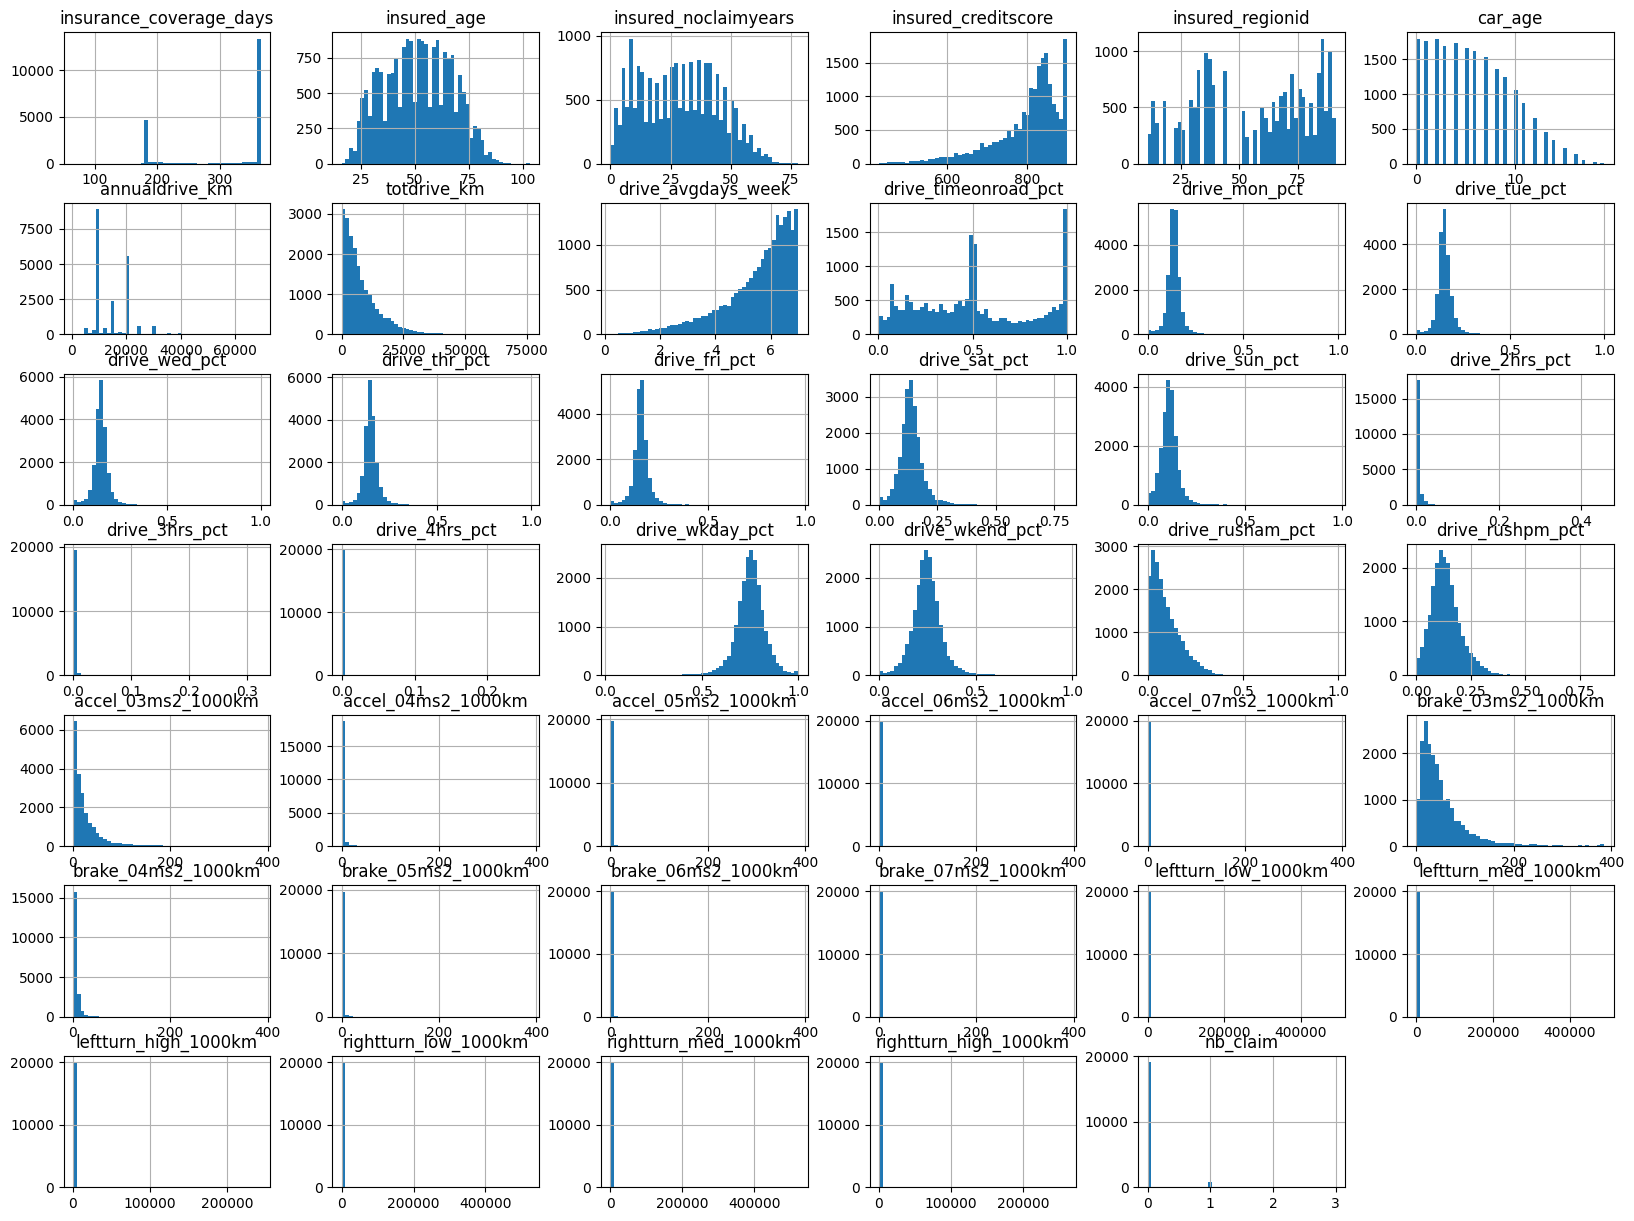

In [26]:
X_train.hist(figsize=(20, 15), bins=50)

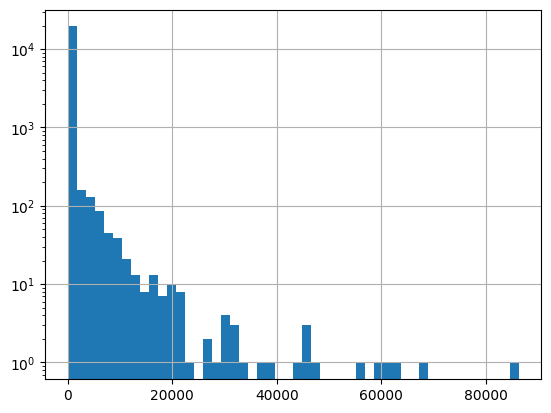

In [14]:
y_train.hist(bins=50)
plt.yscale('log')

Potrei scegliere a bunch of models e assessare le performance per ogni azione che svolgo sul dataset.

* Scelgo solo random forest perché altrimenti ho troppe robe da provare.

I test da svolgere sono: (sempre in cross validation)

- Mutual information

1. Random prediction (predicting random values)
2. Constant prediction
3. Performance of model without doing nothing

5. Applying log to ouptuts
6. Normalization of features
7. Binning
8. PCA (standardized, continuos variables, use it for feature selection maybe)
9. K-Means Clustering to add a new feature

## Study feature importance with mutual information

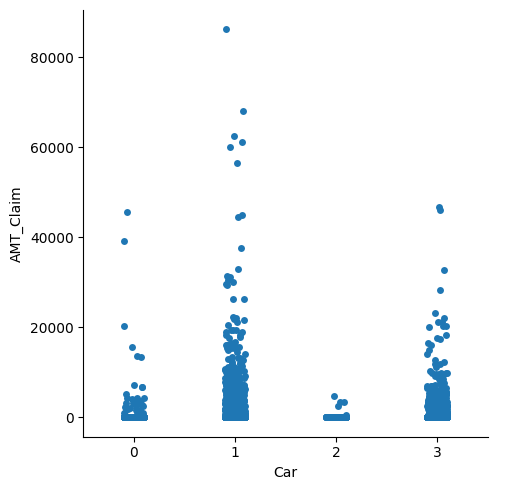

In [15]:
sns.catplot(pd.concat([X_train,y_train],axis=1),x="Car",y="AMT_Claim")
# "Commercial": 0,
# "Commute":1,
# "Farmer":2,
#  "Private":3})

In [16]:
mir = mutual_info_regression(X_train,y_train)

In [17]:
mir_scores = pd.Series(mir,name="MIR Scores",index=X_train.columns).sort_values(ascending=False)


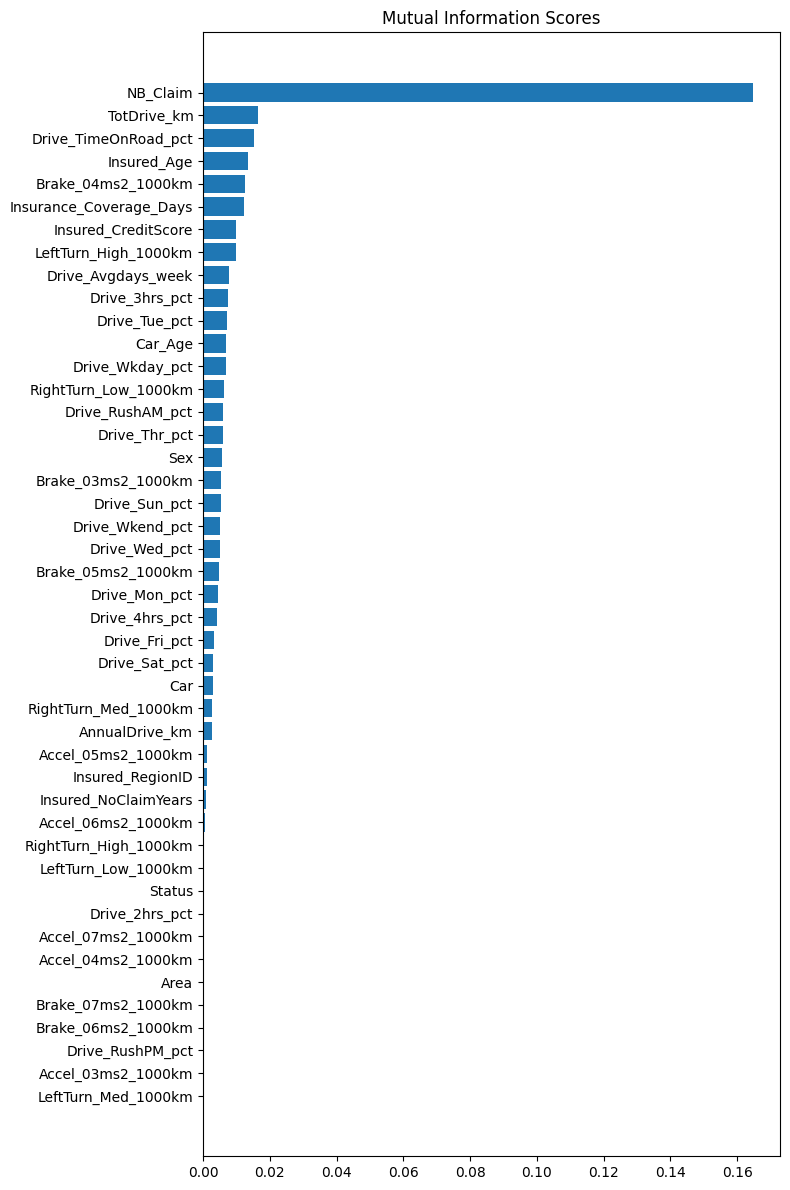

In [18]:
# Sort mutual information scores (descending order)
mir_scores_sorted = mir_scores.sort_values(ascending=True)  # ascending=True for barh (bottom=lowest, top=highest)

# Plot
plt.figure(figsize=(8, 12))  # width x height

width = np.arange(len(mir_scores_sorted))
ticks = list(mir_scores_sorted.index)

plt.barh(width, mir_scores_sorted)
plt.yticks(width, ticks)
plt.title("Mutual Information Scores")

plt.tight_layout()
plt.show()


## Let's start with the baselines

### Random prediction model
Doing no data transformation whatsover (keeping y not log-transformed)

In [19]:
np.min(y_train), np.max(y_train)

(0.0, 86235.28)

In [20]:
def my_random_model(size=1):
    return np.random.random(size)*np.max(y_train)

In [21]:
mean_squared_log_error(y_train,my_random_model(len(y_train)))

104.16774931711228

In [22]:
error = []
for maximum_value in np.linspace(0,np.max(y_train),100):
    error.append(mean_squared_log_error(y_train,np.random.random(len(y_train))*maximum_value))

Text(0, 0.5, 'MSLE')

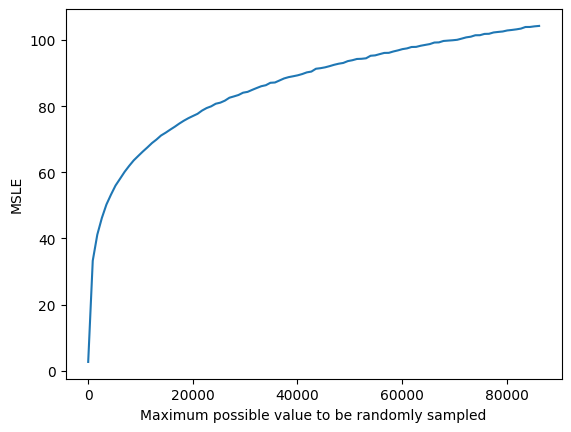

In [23]:
plt.plot(np.linspace(0,np.max(y_train),100),error)
plt.xlabel("Maximum possible value to be randomly sampled")
plt.ylabel("MSLE")

Let's try to zoom in.

I should take averages for each maximum value. This is a function of a random variable. You are interested in the expectations of MSLE fixing the maximum value. 

In [24]:
rand_error_zoom     = []
rand_error_zoom_std = []

for maximum_value in np.linspace(0,1.5,100):
    # iterate 100 times and take the average and std
    running_msle = []
    for _ in range(1000):
        running_msle.append(mean_squared_log_error(y_train,np.random.random(len(y_train))*maximum_value))
    
    rand_error_zoom.append(np.mean(running_msle))
    rand_error_zoom_std.append(np.std(running_msle))
    
    #rand_error_zoom.append(mean_squared_log_error(y_train,np.random.random(len(y_train))*maximum_value))


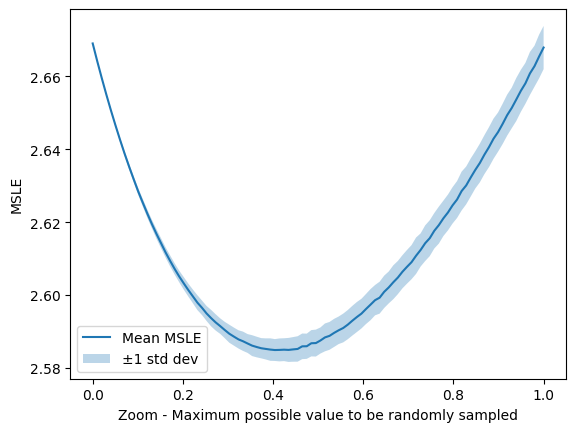

In [25]:
x = np.linspace(0, 1, 100)
y = np.array(rand_error_zoom)
yerr = np.array(rand_error_zoom_std)

plt.plot(x, y, label='Mean MSLE')
plt.fill_between(x, y - yerr, y + yerr, alpha=0.3, label='±1 std dev')
plt.xlabel("Zoom - Maximum possible value to be randomly sampled")
plt.ylabel("MSLE")
plt.legend()


What is it that we would like to minimize in this case? The mean value? The variance? Is there a formula to compute these?

### Constant prediction model

In [26]:
error_const = []
for constant_value in np.linspace(0,np.max(y_train),1000):
    error_const.append(mean_squared_log_error(y_train,np.array([constant_value for _ in y_train])))

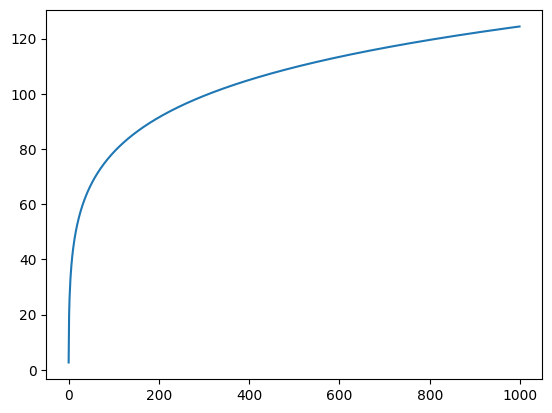

In [27]:
plt.plot(error_const)

In [28]:
closer_error = [mean_squared_log_error(y_train,np.array([constant_value for _ in y_train])) for constant_value in np.linspace(0,1,100)]

In [29]:
from scipy.optimize import minimize

In [30]:
def objective(y):
    return mean_squared_log_error(y_train,np.array([y for _ in range(len(y_train))]))

In [31]:
minimize(objective,x0=.5)

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 2.5610862840702713
        x: [ 3.890e-01]
      nit: 3
      jac: [ 9.954e-06]
 hess_inv: [[ 9.724e-01]]
     nfev: 8
     njev: 4

Text(0.2, 2.65, 'Min error obtained with \nconstant pred y=3.890e-01\n loss=2.561')

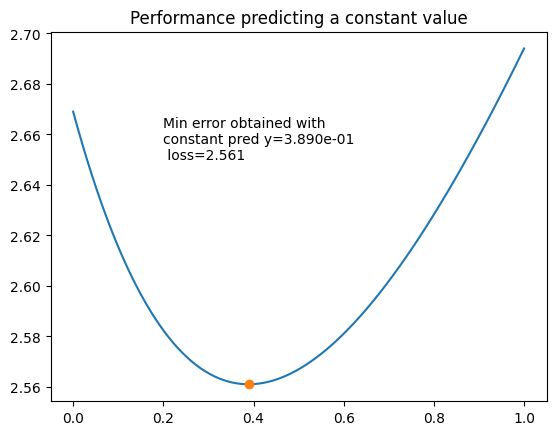

In [38]:
constant_values = np.linspace(0,1,100)
plt.plot(constant_values,closer_error)
plt.title("Performance predicting a constant value")
plt.plot(3.890e-01,2.561,"o")

plt.text(.2,2.65,f"Min error obtained with \nconstant pred y=3.890e-01\n loss=2.561")

I find that a naive model, predicting a constant value $y_{pred} = ~0.4$ achieves a loss of $l = ~2.561$.

This is the best naive baseline we want to defeat, using data science.

## Performance of model without doing nothing

In [27]:
rf = RandomForestRegressor(verbose=10,n_jobs=-1)
rf

RandomForestRegressor(n_jobs=-1, verbose=10)

In [40]:
scores = cross_val_score(rf, X_train, y_train, cv=5, n_jobs=-1,verbose=4,scoring=make_scorer(mean_squared_log_error))

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.


building tree 1 of 100building tree 2 of 100

building tree 3 of 100building tree 4 of 100

building tree 1 of 100
building tree 2 of 100building tree 1 of 100

building tree 2 of 100
building tree 3 of 100
building tree 4 of 100
building tree 3 of 100
building tree 4 of 100
building tree 1 of 100building tree 2 of 100

building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 5 of 100
building tree 6 of 100
building tree 6 of 100building tree 7 of 100
building tree 8 of 100

building tree 7 of 100building tree 8 of 100
building tree 5 of 100

building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100


[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:    1.1s


building tree 9 of 100
building tree 10 of 100
building tree 11 of 100building tree 12 of 100
building tree 9 of 100

building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 10 of 100
building tree 12 of 100building tree 11 of 100
building tree 12 of 100

building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 13 of 100
building tree 13 of 100
building tree 14 of 100building tree 15 of 100

building tree 16 of 100
building tree 14 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 15 of 100
building tree 16 of 100
building tree 16 of 100
building tree 14 of 100


[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    1.7s


...

[Parallel(n_jobs=-1)]: Done  77 tasks      | elapsed:    3.5s


building tree 84 of 100
building tree 85 of 100
building tree 86 of 100
building tree 87 of 100
building tree 88 of 100
building tree 89 of 100
building tree 90 of 100building tree 91 of 100

building tree 92 of 100
building tree 93 of 100
building tree 94 of 100building tree 95 of 100



[Parallel(n_jobs=-1)]: Done  90 tasks      | elapsed:    4.3s


building tree 96 of 100
building tree 97 of 100
building tree 98 of 100
building tree 99 of 100
building tree 100 of 100
[CV] END ................................ score: (test=0.457) total time=   5.0s


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    4.7s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done  24 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done  53 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done  64 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done  77 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done  90 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   27.5s finished


In [41]:
print("%0.2f accuracy with a standard deviation of %0.2f" % (scores.mean(), scores.std()))

0.36 accuracy with a standard deviation of 0.06


This is NOT a trained model. It's needed for model selection (I think). Then, one should fit the actual random forest to have a trained model.

Let's try other models.

- GradientBoosting cannot be used together with MSLE for it produces negative outputs. I'd need to pre-process the data, which is something I'm planning to do in the next steps. 
- SVR is normalization dependent. This also implies that I will finetune it later (possibily with NNs too)


In [ ]:
models = {
    #'RandomForest': RandomForestRegressor(),
    #'GradientBoosting': GradientBoostingRegressor(),
    'SVR': SVR()
}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train,
                             scoring=make_scorer(mean_squared_log_error),
                             cv=5, n_jobs=-1, verbose=0)
    print(f"{name} - RMSLE: {scores.mean():.4f} ± {scores.std():.4f}")


I found that RandomForest is the easiest model to train and it gives very good performance compared to the naive baseline. Let's see the performance on the whole train set.

In [28]:
X_train.keys

['insurance_coverage_days',
 'insured_age',
 'insured_noclaimyears',
 'insured_creditscore',
 'insured_regionid',
 'car_age',
 'annualdrive_km',
 'totdrive_km',
 'drive_avgdays_week',
 'drive_timeonroad_pct',
 'drive_mon_pct',
 'drive_tue_pct',
 'drive_wed_pct',
 'drive_thr_pct',
 'drive_fri_pct',
 'drive_sat_pct',
 'drive_sun_pct',
 'drive_2hrs_pct',
 'drive_3hrs_pct',
 'drive_4hrs_pct',
 'drive_wkday_pct',
 'drive_wkend_pct',
 'drive_rusham_pct',
 'drive_rushpm_pct',
 'accel_03ms2_1000km',
 'accel_04ms2_1000km',
 'accel_05ms2_1000km',
 'accel_06ms2_1000km',
 'accel_07ms2_1000km',
 'brake_03ms2_1000km',
 'brake_04ms2_1000km',
 'brake_05ms2_1000km',
 'brake_06ms2_1000km',
 'brake_07ms2_1000km',
 'leftturn_low_1000km',
 'leftturn_med_1000km',
 'leftturn_high_1000km',
 'rightturn_low_1000km',
 'rightturn_med_1000km',
 'rightturn_high_1000km',
 'nb_claim']

In [29]:
rf.fit(X_train,y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.


building tree 1 of 100
building tree 2 of 100
building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100


[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    0.9s


building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100building tree 20 of 100

building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100


[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    1.4s


...

building tree 83 of 100
building tree 84 of 100
building tree 85 of 100
building tree 86 of 100
building tree 87 of 100
building tree 88 of 100
building tree 89 of 100
building tree 90 of 100
building tree 91 of 100
building tree 92 of 100
building tree 93 of 100
building tree 94 of 100
building tree 95 of 100
building tree 96 of 100


[Parallel(n_jobs=-1)]: Done  90 tasks      | elapsed:    6.0s


building tree 97 of 100
building tree 98 of 100
building tree 99 of 100
building tree 100 of 100


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    6.8s finished


RandomForestRegressor(n_jobs=-1, verbose=10)

In [30]:
y_pred = rf.predict(X_train)

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done  17 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done  24 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done  53 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done  64 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done  77 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done  90 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.1s finished


In [31]:
mean_squared_log_error(y_train,y_pred)

0.22808866434646788

In [32]:
import joblib

# Save the model to a file
joblib.dump(rf, 'random_forest_model.joblib')

['random_forest_model.joblib']

The performance of the RandomForest on the train set is 0.24 vs. 2.68 of the constant model.

Mi mancano:

5. Applying log to ouptuts
6. Normalization of features -> GradientBoosting, SVM, NN
7. Binning
8. PCA (standardized, continuos variables, use it for feature selection maybe)
8. Use MRI in some way??
9. K-Means Clustering to add a new feature